### Імпорт бібліотек, встановлення налаштувань відображення, завантаження файлу

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [3]:
df = pd.read_csv("D:\\my_projects\\kursah\\data\\raw\\result_test_10000.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   price_UAH           10000 non-null  str  
 1   price_USD           10000 non-null  str  
 2   title               10000 non-null  str  
 3   location_list       10000 non-null  str  
 4   details_list        10000 non-null  str  
 5   advantages_list     10000 non-null  str  
 6   description         10000 non-null  str  
 7   created_at          10000 non-null  str  
 8   facilities_list     10000 non-null  str  
 9   technically_tested  10000 non-null  str  
 10  seller_name         10000 non-null  str  
 11  seller_trust        10000 non-null  str  
 12  city                10000 non-null  str  
 13  plus_text           10000 non-null  str  
 14  url                 10000 non-null  str  
 15  page                10000 non-null  int64
dtypes: int64(1), str(15)
memory usage: 1.2 MB


## 1. Очистка і формування стовпчиків для аналізу

### Загальні стовпці з ціною, id, кількістю кімнат

In [5]:
df['id'] = df['title'].str.extract(r'ID (\d+)')
df['rooms'] = df['title'].str.extract(r'(\d+)к квартири', expand=False).astype('Int64')
df['price_UAH'] = df['price_UAH'].str.replace(' ', '').str.extract(r'(\d+)', expand=False).astype('Int64')
df['price_USD'] = df['price_USD'].str.replace(' ', '').str.extract(r'(\d+)', expand=False).astype('Int64')

### Стовпець дати

In [6]:
months = {
    'січ': '01', 'лют': '02', 'бер': '03', 'кві': '04',
    'тра': '05', 'чер': '06', 'лип': '07', 'сер': '08',
    'вер': '09', 'жов': '10', 'лис': '11', 'гру': '12'
}
extracted = df['created_at'].str.extract(r'(\d+)\s+([а-яіїєґ]+)\.*\s*(\d{4})?')
extracted.columns = ['day', 'month_abbr', 'year']
current_year = str(pd.Timestamp.now().year)
extracted['year'] = extracted['year'].fillna(current_year)
extracted['month'] = extracted['month_abbr'].map(months)

df['date'] = pd.to_datetime(
    extracted['day'] + '.' + extracted['month'] + '.' + extracted['year'],
    format='%d.%m.%Y'
)

### Створення стовпців з локацією

In [7]:
df['city_name'] = df['city'].str.split(',').str[2].str.strip().astype(str)
df['district'] = df['location_list'].str.extract(r'район\s+([^|]+)')[0].str.strip()
df['metro'] = df['location_list'].str.extract(r'метро\s+([^|]+)')[0].str.strip()
df['address'] = df['title'].str.extract(r'на\s+((?:вул|просп|бул|пров|пл|шосе|наб)\.?\s+.+?)(?=\s*•)')[0].str.strip()

### Створення стовпців з інформацією про продавця

In [8]:
df['seller'] = df['seller_name'].str.extract(r'\n([А-ЯІЇЄҐа-яA-Za-z][^\n\d]+?)(?:\n|$)')[0].str.strip()

def experience_to_months(text):
    if pd.isna(text):
        return 0
    
    years  = re.search(r'(\d+)\+?\s*рок|(\d+)\+?\s*рік', text)
    months = re.search(r'(\d+)\s*місяц', text)
    days   = re.search(r'(\d+)\s*дн', text)
    
    total = 0
    if years:
        total += int(years.group(1) or years.group(2)) * 12
    if months:
        total += int(months.group(1))
    if days:
        total += int(days.group(1)) / 30
    
    return total

def categorize(months):
    if months < 12:
        return 'Новачок'        # < 1 року
    elif months < 36:
        return 'Досвідчений'     # 1–3 роки
    elif months < 60:
        return 'Професіонал'  # 3–5 років
    else:
        return 'Експерт'      # 5+ років
    
df['experience_months'] = df['seller_trust'].apply(experience_to_months).round().astype(int)
df['seller_level'] = df['experience_months'].apply(categorize)

print(df[['experience_months', 'seller_level']].head(10))

   experience_months seller_level
0                 60      Експерт
1                  0      Новачок
2                 60      Експерт
3                 60      Експерт
4                 51  Професіонал
5                 10      Новачок
6                 60      Експерт
7                 22  Досвідчений
8                 35  Досвідчений
9                 60      Експерт


### Створення стовпців по площі 

In [9]:
df['area_total']   = df['details_list'].str.extract(r'[Зз]агальна площа\s+([\d.]+)')[0]
df['area_living']  = df['details_list'].str.extract(r'житлова\s+([\d.]+)')[0]
df['area_kitchen'] = df['details_list'].str.extract(r'кухня\s+([\d.]+)')[0]

for col in ['area_total', 'area_living', 'area_kitchen']:
    df[col] = df[col].astype(float)

print(df[['area_total', 'area_living', 'area_kitchen']].head(10))

   area_total  area_living  area_kitchen
0        27.0         16.0           6.0
1        56.8         39.7           5.3
2       140.0         55.4          34.2
3        87.0         60.0          20.0
4       198.8        113.6          14.0
5       132.0          NaN          22.0
6       193.1        106.2          20.2
7        44.3         14.4          10.0
8       150.0        120.0          17.0
9        60.0         27.0          12.0


### Створення стовпців поверху квартири та поверховості будинку

In [10]:
df['floor_current'] = df['technically_tested'].str.extract(r'(\d+)\s+поверх з')[0].astype('Int64')
df['floor_total']   = df['technically_tested'].str.extract(r'поверх з\s+(\d+)')[0].astype('Int64')

print(df[['floor_current', 'floor_total']].head(10))

   floor_current  floor_total
0              3            4
1              5            6
2              7            8
3              5           16
4             14           15
5             18           26
6              4           17
7              3           25
8              2            6
9              3           12


### Створення бінарних стовпців по особливостям планування

In [11]:
df['kitchen_studio'] = df['plus_text'].str.extract(r'(Кухня-студія)', flags=re.IGNORECASE)
df['penthouse']      = df['plus_text'].str.extract(r'(Пентхаус)', flags=re.IGNORECASE)
df['multilevel']     = df['plus_text'].str.extract(r'(Багаторівнева)', flags=re.IGNORECASE)

for col in ['kitchen_studio', 'penthouse', 'multilevel']:
    df[col] = df[col].notna().astype(int)

print(df[['kitchen_studio', 'penthouse', 'multilevel']].head(20))

    kitchen_studio  penthouse  multilevel
0                1          0           0
1                0          0           0
2                1          1           1
3                1          0           0
4                1          0           1
5                0          0           0
6                0          0           0
7                0          0           0
8                0          0           0
9                1          0           0
10               0          0           0
11               1          0           0
12               0          0           0
13               0          0           0
14               1          0           0
15               1          0           0
16               1          0           0
17               0          0           0
18               0          0           0
19               0          0           0


### Створення стовпця про наявність укриття 

In [12]:
df['shelter'] = df['advantages_list'].str.extract(r'((?:У|у)криття[^|]+)')[0].str.strip()

def extract_shelter_context(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\S+\s+){0,2}\S*[Уу]крит\S*(\s+\S+){0,2}', text)
    return match.group().strip() if match else None

df['shelter_context'] = df['description'].apply(extract_shelter_context)
df['shelter_plus'] = df['plus_text'].apply(extract_shelter_context)

print(df['shelter'].head(10))

0    Укриття в будинку
1                  NaN
2                  NaN
3                  NaN
4                  NaN
5    Укриття в будинку
6                  NaN
7    Укриття в будинку
8    Укриття в будинку
9                  NaN
Name: shelter, dtype: str


Зведення до єдиної бінарної колонки по наявності укриття:

In [13]:
df['shelter_plus'] = df['shelter_plus'].str.contains('укриття', case=False, na=False).astype(int)
df['shelter_context'] = df['shelter_context'].str.contains('укриття', case=False, na=False).astype(int)
df['shelter'] = df['shelter'].str.contains('укриття', case=False, na=False).astype(int)

shelter_columns = ['shelter_plus', 'shelter_context', 'shelter']
df['has_shelter'] = df[shelter_columns].any(axis=1).astype(int)


# print(df[['shelter_plus', 'shelter_context', 'shelter']])
print(df['has_shelter'].value_counts())

has_shelter
0    7094
1    2906
Name: count, dtype: int64


### Створення стовпця дозволу проживання з тваринами

In [14]:
df['pets'] = df['facilities_list'].str.extract(r'((?:[Мм]ожна|[Нн]е можна|[Бб]ез)\s+з?\s*тварин[^|]*)')[0].str.strip()

def extract_bober_context(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\S+\s+){0,2}\S*[Тт]варин\S*(\s+\S+){0,2}', text)
    return match.group().strip() if match else None

df['pets_desc'] = df['description'].apply(extract_bober_context)

Зведення до єдиної бінарної колонки по дозволу проживання з тваринами:

In [15]:
df['pets'] = df['pets'].fillna('Не вказано')

def classify_pets_desc(text):
    if pd.isna(text):
        return None
    text_lower = text.lower()
    
    if re.search(r'без тварин|не можна|заборон|неможлив|не приймаємо тварин|не розглядаєть|не розглядаємо', text_lower):
        return 'не можна'
    
    if re.search(r'тварин|тваринк', text_lower):
        return 'можна'
    
    return None

df['pets_classified'] = df['pets_desc'].apply(classify_pets_desc)

df['pets'] = df['pets'].fillna(df['pets_classified']).fillna('не вказано')


print(df['pets'].value_counts())

pets
Не вказано           5220
Без тварин           2833
Можна з тваринами    1947
Name: count, dtype: int64


### Створення стовпців забезпеченості при відсутності електроенергії.   

In [16]:
features = {
    'no_light_internet':    'є інтернет',
    'no_light_mobile_connection':      'є мобільний зв\'язок',
    'no_light_water':       'є водопостачання',
    'no_light_heating':     'працює опалення',
    'no_light_gas':         'є газ',
    'no_light_elevator':    'працює ліфт'
}

for col, keyword in features.items():
    df[col] = df['plus_text'].str.contains(keyword, case=False, na=False).astype(int)

df[['no_light_internet', 'no_light_mobile_connection', 'no_light_water', 'no_light_heating', 'no_light_gas',
           'no_light_elevator']].head(10)

,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator
0,1,0,0,0,0,0
1,1,0,1,1,1,0
2,1,0,1,1,1,0
3,1,0,1,1,0,1
4,1,0,0,1,0,1
5,0,0,0,0,0,0
6,0,0,0,0,0,0
7,1,1,1,1,0,1
8,0,0,0,0,0,0
9,1,1,1,0,1,0


### **Створення кінцевого датасету**

In [17]:
cl_df = df[['id', 'rooms', 'price_UAH', 'price_USD', 'date', 'city_name', 'district', 'metro', 'address', 'seller',
            'experience_months', 'seller_level', 'area_total', 'area_living', 'area_kitchen', 'floor_current', 
            'floor_total', 'kitchen_studio', 'penthouse', 'multilevel', 'has_shelter', 'pets', 'no_light_internet',
            'no_light_mobile_connection', 'no_light_water', 'no_light_heating', 'no_light_gas', 'no_light_elevator',
            'url']].copy()

print(cl_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          9998 non-null   str           
 1   rooms                       9998 non-null   Int64         
 2   price_UAH                   9998 non-null   Int64         
 3   price_USD                   9998 non-null   Int64         
 4   date                        9998 non-null   datetime64[us]
 5   city_name                   9933 non-null   str           
 6   district                    8941 non-null   str           
 7   metro                       3492 non-null   str           
 8   address                     9751 non-null   str           
 9   seller                      9995 non-null   str           
 10  experience_months           10000 non-null  int64         
 11  seller_level                10000 non-null  str           
 12  ar

## 2. EDA (Exploratory Data Analysis)

### 1. Обробка пропущених значень

In [18]:
cl_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          9998 non-null   str           
 1   rooms                       9998 non-null   Int64         
 2   price_UAH                   9998 non-null   Int64         
 3   price_USD                   9998 non-null   Int64         
 4   date                        9998 non-null   datetime64[us]
 5   city_name                   9933 non-null   str           
 6   district                    8941 non-null   str           
 7   metro                       3492 non-null   str           
 8   address                     9751 non-null   str           
 9   seller                      9995 non-null   str           
 10  experience_months           10000 non-null  int64         
 11  seller_level                10000 non-null  str           
 12  ar

#### Перевірка і видалення дублікатів

Спочатку перевіряємо повністю дублюючі рядки і видаляємо дублікати. 

In [19]:
n_duplicates = cl_df.duplicated().sum()
print(f"Кількість повних дублікатів: {n_duplicates}")
print(f"Це {n_duplicates / len(cl_df) * 100:.2f}% від усіх рядків ({len(cl_df)} загалом)")

cl_df = cl_df.drop_duplicates()
print(f"\nПісля видалення: {len(cl_df)} рядків залишилось")

Кількість повних дублікатів: 201
Це 2.01% від усіх рядків (10000 загалом)

Після видалення: 9799 рядків залишилось


Далі перевіряємо і видаляємо дублікати по колонці `id`

In [20]:
n_duplicates_id = cl_df.duplicated(subset=['id']).sum()
print(f"Кількість дублікатів по колонці id: {n_duplicates_id}")
print(f"Це {n_duplicates_id / len(cl_df) * 100:.2f}% від усіх рядків ({len(cl_df)} загалом)")

cl_df = cl_df.drop_duplicates(subset=['id'])
print(f"\nПісля видалення: {len(cl_df)} рядків залишилось")

Кількість дублікатів по колонці id: 10
Це 0.10% від усіх рядків (9799 загалом)

Після видалення: 9789 рядків залишилось


Додатково перевіряємо і видаляємо дублікати за ціною, площею та адресою. Скоріш за все це спам рієлторів для підняття оголошень в топ при повторному опублікуванні.

In [21]:
# 1. Рахуємо загальну кількість "схованих" дублікатів
columns_to_check = ['price_UAH', 'rooms', 'area_total', 'floor_current', 'address']
dup_count = cl_df.duplicated(subset=columns_to_check).sum()

print(f"Знайдено прихованих дублікатів (рієлторського спаму): {dup_count}")

# 2. Дістаємо всі ці рядки (і оригінали, і їхні копії)
semantic_duplicates = cl_df[cl_df.duplicated(subset=columns_to_check, keep=False)]

# 3. Виводимо їх на екран, відсортувавши за ціною та площею
if not semantic_duplicates.empty:
    print("\nОсь як вони виглядають:")
    print(semantic_duplicates.sort_values(by=['price_UAH', 'area_total'])[
        ['id', 'price_UAH', 'rooms', 'area_total', 'floor_current', 'address']
    ].head(20))

Знайдено прихованих дублікатів (рієлторського спаму): 94

Ось як вони виглядають:
            id  price_UAH  rooms  area_total  floor_current  \
4249  33955060       5000      1        20.0              3   
7665  33510975       5000      1        20.0              3   
7593  33526587       6000      1        20.0              1   
8082  33409948       6000      1        20.0              1   
8250  33357853       6000      1        20.0              3   
8363  33322073       6000      1        20.0              3   
8606  33216945       6000      1        20.0              2   
8739  33166565       6000      1        20.0              2   
2495  34036223       6000      1        22.0              6   
3744  33989698       6000      1        22.0              6   
7652  33513930       6000      1        22.0              2   
8108  33400006       6000      1        22.0              2   
5345  33861527       6500      1        25.0              1   
7297  33535555       6500      1    

In [22]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")
cl_df = cl_df.drop_duplicates(subset=['price_UAH', 'rooms', 'area_total', 'floor_current', 'address'], keep='first')
print(f"Довжина датасету після видалення дублікатів: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 9789
Довжина датасету після видалення дублікатів: 9695


Також видаляємо схожі оголошення від одного автора за основною колонкою `seller`

In [23]:
# 1. Рахуємо загальну кількість "схованих" дублікатів
columns_to_check = ['price_UAH', 'rooms', 'area_total', 'floor_current', 'seller']
dup_count = cl_df.duplicated(subset=columns_to_check).sum()

print(f"Знайдено прихованих дублікатів (рієлторського спаму): {dup_count}")

# 2. Дістаємо всі ці рядки (і оригінали, і їхні копії)
semantic_duplicates = cl_df[cl_df.duplicated(subset=columns_to_check, keep=False)]

# 3. Виводимо їх на екран, відсортувавши за ціною та площею
if not semantic_duplicates.empty:
    print("\nОсь як вони виглядають:")
    print(semantic_duplicates.sort_values(by=['price_UAH', 'area_total'])[
        ['id', 'price_UAH', 'rooms', 'area_total', 'floor_current', 'seller']
    ].head(20))

Знайдено прихованих дублікатів (рієлторського спаму): 73

Ось як вони виглядають:
            id  price_UAH  rooms  area_total  floor_current         seller
3267  34012904       4412      1        34.0              3  Анна Тодорова
4564  33930357       4412      1        34.0              3  Анна Тодорова
9329  32845255       5000      1        33.0              1   Олександр ОС
9354  32833533       5000      1        33.0              1   Олександр ОС
8737  33166694       5500      1        20.0              3          Ирина
8934  33062828       5500      1        20.0              3          Ирина
9015  33019329       5500      1        20.0              1          Ирина
9068  32992543       5500      1        20.0              2          Ирина
9069  32992197       5500      1        20.0              2          Ирина
9260  32890231       5500      1        20.0              4          Ирина
9283  32879037       5500      1        20.0              4          Ирина
9314  32856311    

In [24]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")
cl_df = cl_df.drop_duplicates(subset=['price_UAH', 'rooms', 'area_total', 'floor_current', 'seller'], keep='first')
print(f"Довжина датасету після видалення дублікатів: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 9695
Довжина датасету після видалення дублікатів: 9622


Також виконаємо пошук незважаючи на ціну і площу (їх можуть спеціально змінювати агенства) за кількістю кімнат, поверхом, містом і точною адресою. Під точною адресою я маю на увазі адреси з вказаним номером будинку, а не лише вулицею. Не точні адреси було вирішено не брати тому що на одній вулиці дійсно можуть бути квартири з однаковою кількістю кімнат і поверхом.

In [25]:
pattern = r'\d+[А-Яа-яa-zA-Z]?\s*$'
has_number = cl_df['address'].str.contains(pattern, na=False, regex=True)
df_precise_for_check = cl_df[has_number]
sneaky_duplicates = df_precise_for_check[df_precise_for_check.duplicated(subset=['rooms', 'floor_current', 'address', 'city_name'],
                                                                          keep=False)]

if not sneaky_duplicates.empty:
    print("Знайдено квартири за ТОЧНОЮ адресою, але з різною ціною/площею:")
    print(f"Знайдено рієлторських дублікатів: {len(sneaky_duplicates)}")
    print(sneaky_duplicates.sort_values(by=['address', 'floor_current'])[
        ['address', 'floor_current', 'price_UAH', 'area_total', 'seller', 'url']
    ].head(20))
else:
    print("Все ідеально чисто, хитрих дублікатів немає!")

Знайдено квартири за ТОЧНОЮ адресою, але з різною ціною/площею:
Знайдено рієлторських дублікатів: 707
                                  address  floor_current  price_UAH  \
5659                бул. Лесі Українки 7В             11      88140   
8705                бул. Лесі Українки 7В             11      48477   
8040                бул. Лесі Українки 7В             12      96954   
8224                бул. Лесі Українки 7В             12      96954   
6101                 бул. Французький 60А             13      17628   
8850                 бул. Французький 60А             13      30849   
3166                   вул. 600-річчя 66В             10      17000   
4213                   вул. 600-річчя 66В             10      17000   
105   вул. 93-ї Холодноярської Бригади 4А              4      44120   
5657  вул. 93-ї Холодноярської Бригади 4А              4      44070   
8409             вул. Євгена Сверстюка 6А              7      26000   
9719             вул. Євгена Сверстюка 6А     

In [26]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")

cl_df = cl_df.sort_values(by='date', ascending=False)

# Для більшої точності для перевірки беремо лише точні адреси (з вказаним номером будинку), а адреси лише з вулицею не беремо.
pattern = r'\d+[А-Яа-яa-zA-Z]?\s*$'
has_number = cl_df['address'].str.contains(pattern, na=False, regex=True)
df_precise = cl_df[has_number].copy() # Адреси з номером (закінчуються на цифру)
df_broad = cl_df[~has_number].copy() # Тільки вулиці (закінчуються на букву)
df_precise = df_precise.drop_duplicates(subset=['city_name', 'address', 'rooms', 'floor_current'], keep='first')
cl_df = pd.concat([df_precise, df_broad])

print(f"Готово! Залишилося унікальних реальних квартир: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 9622
Готово! Залишилося унікальних реальних квартир: 9239


#### Видалення пустих рядків і заповнення

Також видаляємо рядки з відсутнім поверхом. Це може бути через неперевірену квартиру або збій - обидва варіанти нам не підходять.

In [27]:
print(f"До: {len(cl_df)}")
cl_df = cl_df.dropna(subset=['floor_current'])
print(f"Після: {len(cl_df)}")

До: 9239
Після: 9221


В наступних комірках заповнюємо пропущені значення медіаною групи і загальною. Це так звана Імпутація. Оскільки це площа кухні і житлова за орієнтир беремо кількість кімнат. Також порівнюємо медіану і середнє до та після заповнення.

In [28]:
print(cl_df['area_kitchen'].median())
print(cl_df['area_kitchen'].mean())
print(cl_df['area_living'].median())
print(cl_df['area_living'].mean())

12.0
13.673011085331272
30.0
35.950772266065385


In [29]:
# Заповнюємо площу медіаною на основі кількості кімнат
cl_df['area_living'] = cl_df['area_living'].fillna(
    cl_df.groupby('rooms')['area_living'].transform('median')
)


cl_df['area_kitchen'] = cl_df['area_kitchen'].fillna(
    cl_df.groupby('rooms')['area_kitchen'].transform('median')
)

# Залишок заповнюємо просто загальною медіаною
cl_df['area_kitchen'] = cl_df['area_kitchen'].fillna(cl_df['area_kitchen'].median())
cl_df['area_living'] = cl_df['area_living'].fillna(cl_df['area_living'].median())

In [30]:
print(cl_df['area_kitchen'].median())
print(cl_df['area_kitchen'].mean())
print(cl_df['area_living'].median())
print(cl_df['area_living'].mean())

12.0
13.468004554820519
30.0
34.666015616527496


Після заповнення пропусків спостерігаються незначні зміни у середньому значення та медіані, проте вони знаходяться в межах дозволеного. 

Наступним кроком видаляємо рядки без адреси і без міста. Залишити їх не можемо, тому що без цієї інформації не можливо перевірити їх унікальність розташування. Додатково видаляємо декілька оголошень без імені продавця, яке можливо відсутнє через збій парсера даних.

In [31]:
print(f"До: {len(cl_df)}")
cl_df = cl_df.dropna(subset=['address'])
cl_df = cl_df.dropna(subset=['city_name'])
cl_df = cl_df.dropna(subset=['seller'])
print(f"Після: {len(cl_df)}")

До: 9221
Після: 8922


Ще заповнюємо відсутні значення у стовпці метро 'Немає метро' і створюємо для майбутніх дій бінарний стовпець 'has_metro'.
Відсутні значення у стовпці район також заповнюємо 'Невідомий район'.

In [32]:
cl_df['metro'] = cl_df['metro'].fillna('Немає метро')
cl_df['has_metro'] = (cl_df['metro'] != 'Немає метро').astype(int)


cl_df['district'] = cl_df['district'].fillna('Невідомий район')

Також необхідно відрізати неактуальні оголошення в часі. Так як планується досліджувати вплив зимових обставин на ціноутворення - обмежуємо датасет даними з 01.12.2025 до 31.03.2026 (4 місяці). 

In [33]:
# Дивимося на найстарішу і найновішу дату в базі
print(f"Найстаріше оголошення: {cl_df['date'].min()}")
print(f"Найсвіжіше оголошення: {cl_df['date'].max()}")

Найстаріше оголошення: 2024-07-05 00:00:00
Найсвіжіше оголошення: 2026-03-27 00:00:00


In [34]:
cl_df = cl_df[cl_df['date'] >= '2025-12-01']

print(f"Залишилося актуальних оголошень: {len(cl_df)}")

Залишилося актуальних оголошень: 5692


Також створимо колонку місяця для зручності.

In [35]:
# Створюємо колонку 'year_month'
cl_df['year_month'] = cl_df['date'].dt.to_period('M')

# Розподіл по місяцях для розуміння
print(cl_df['year_month'].value_counts().sort_index())

year_month
2025-12     711
2026-01     801
2026-02    1339
2026-03    2841
Freq: M, Name: count, dtype: int64


Дивимося на результат заповнення порожніх комірок: маємо `5692 з 10000, тобто це ≈56%`. Для даних з парсера сайту це гарний результат, враховуючи що більшість оголошень було видалено по часовому фільтру. І тепер маємо актуальні та очищенні дані.

In [36]:
cl_df.info()

<class 'pandas.DataFrame'>
Index: 5692 entries, 222 to 6208
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          5692 non-null   str           
 1   rooms                       5692 non-null   Int64         
 2   price_UAH                   5692 non-null   Int64         
 3   price_USD                   5692 non-null   Int64         
 4   date                        5692 non-null   datetime64[us]
 5   city_name                   5692 non-null   str           
 6   district                    5692 non-null   str           
 7   metro                       5692 non-null   str           
 8   address                     5692 non-null   str           
 9   seller                      5692 non-null   str           
 10  experience_months           5692 non-null   int64         
 11  seller_level                5692 non-null   str           
 12  area_t

### 2. Перевірка викидів

Спочатку розподілимо колонки по групам для зручності аналізу.

In [37]:
numeric_cols = [
    'price_UAH', 'price_USD',
    'area_total', 'area_living', 'area_kitchen',
    'floor_current', 'floor_total',
    'experience_months', 'rooms'
]

binary_cols = [
    'kitchen_studio', 'penthouse', 'multilevel', 'has_shelter',
    'no_light_internet', 'no_light_mobile_connection',
    'no_light_water', 'no_light_heating', 'no_light_gas',
    'no_light_elevator', 'has_metro'
]

categorical_cols = ['seller_level', 'pets', 'city_name', 'district']

#### 1. Візуалізація (боксплоти)

Використаємо `Boxplots` для наочного виявлення аномалій.

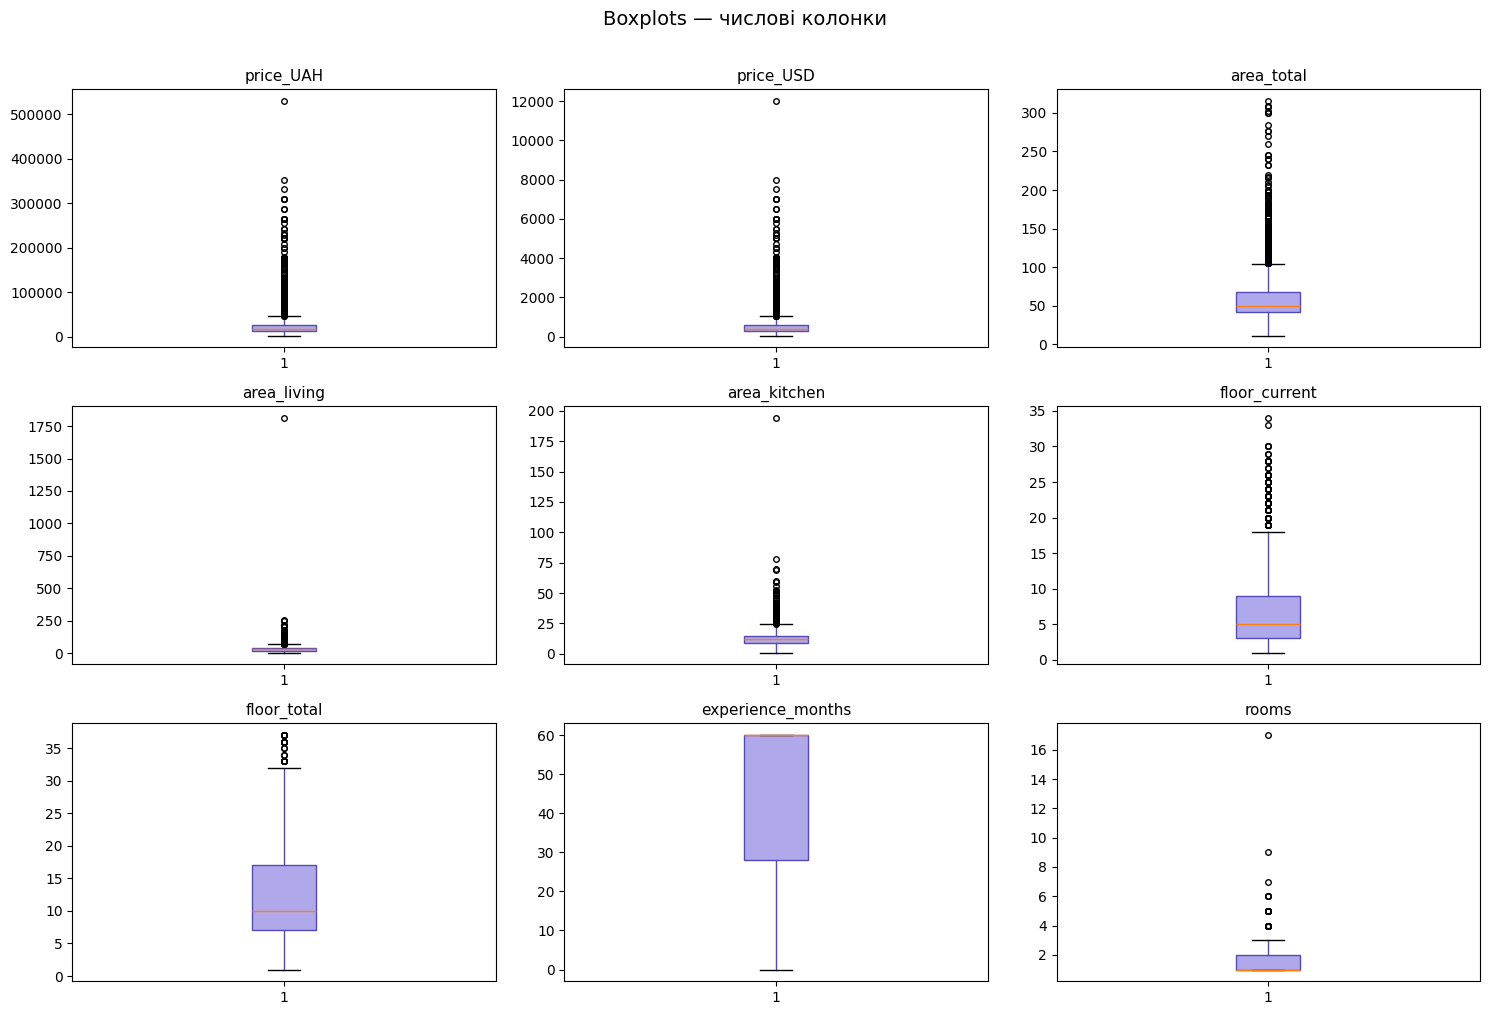

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(cl_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AFA9EC', color='#534AB7'),
                    whiskerprops=dict(color='#534AB7'),
                    flierprops=dict(marker='o', color='#D85A30', markersize=4))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — числові колонки', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Спочатку перевіряємо нижній поріг цін. Так як таких оголошень не багато виконаємо наочну перевірку на достовірність (квартира на довгострокову оренду). За результатом вирішено залишити ці квартири - це дійсно об'єкти найнижчого цінового сегменту на ринку.

In [39]:
# Шукаємо підозріло дешеві об'єкти (менше 4000 грн)
suspicious_low = cl_df[cl_df['price_UAH'] < 4000]

# Виводимо їх, щоб оцінити очима
print(f"Знайдено підозріло дешевих: {len(suspicious_low)}")
suspicious_low[['id', 'price_UAH', 'rooms', 'area_total', 'url']].head(10)

Знайдено підозріло дешевих: 17


,id,price_UAH,rooms,area_total,url
1303,34077319,3500,1,24.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-saltovskiy-yubileynyy-prospekt-34077319.html
1785,34062890,2500,1,30.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-626-yy-mikrorayon-edinstva-krasnodarskaya-ulitsa-34062890.html
1911,34033167,3100,1,35.5,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kamenskoe-dneprovskiy-naddnepryanskiy-50-let-sssr-prospekt-34033167.html
3087,34018397,3000,2,43.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-krivoy-rog-inguletskiy-solnechnaya-ulitsa-34018397.html
4131,33964072,2700,1,19.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-kievskiy-shevchenkovskiy-pereulok-33964072.html
4274,33953474,3999,1,20.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-shevchenkovskiy-pereulok-33953474.html
4353,33944738,3000,1,18.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-kievskiy-chernivetskaya-ulitsa-33944738.html
4571,33929343,3000,1,36.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-saltovskiy-neskorenyh-geroev-truda-ulitsa-33929343.html
5439,33854001,3500,1,18.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-slobodskoy-geroev-harkova-moskovskiy-prospekt-33854001.html
5444,33853735,3000,1,19.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-shishkovka-jilyardi-ulitsa-33853735.html


Для перевірки достовірності ціни квартири створюємо стовпець ціни за квадратний метр. І наочно переглядаємо найдорожчі квартири за квадратний метр в пошуку неправдивих даних.

In [40]:
cl_df['price_per_sqm'] = cl_df['price_UAH'] / cl_df['area_total']

In [41]:
expensive_df = cl_df[cl_df['price_UAH'] > 60000]

print(expensive_df.sort_values(by='price_per_sqm', ascending=False)[
    ['id', 'price_UAH', 'area_total', 'rooms', 'price_per_sqm', 'url']
].head(15))

            id  price_UAH  area_total  rooms  price_per_sqm  \
4532  33930690     264720        51.6      1    5130.232558   
4365  33936983     255896        78.8      2    3247.411168   
4331  33945308     352960       123.6      3     2855.66343   
4415  33937954     123536        49.2      1    2510.894309   
1519  34067954     286780       123.6      3    2320.226537   
3703  33987955     330900       149.5      4    2213.377926   
4060  33963234     110300        51.6      1    2137.596899   
5732  33821239     286455       137.5      4    2083.309091   
6147  33771563     158652        79.3      2    2000.655738   
5091  33884625     264720       132.7      4    1994.875659   
4330  33945295     242660       124.1      3    1955.358582   
6188  33771841     123396        64.4      1    1916.086957   
2582  34030070     141184        74.0      2    1907.891892   
5370  33859530     114712        60.6      1    1892.937294   
3830  33979465     233836       124.1      3    1884.25

За результатами перевірки не було виявлено оголошень з хибними даними, такі квартири дійсно існують і складають преміум сегмет на ринку оренди житлової нерухомості Києва.

In [42]:
cl_df[cl_df['price_UAH'] > 200000].head()

,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
1126,34081972,4,529440,12000,2026-03-20,Київ,Печерськ,Арсенальна,вул. Івана Мазепи 11Б,Валерия Корбут,43,Професіонал,309.0,220.0,50.0,11,26,1,0,0,1,Можна з тваринами,1,0,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-pechersk-ivana-mazepy-yanvarskogo-vosstaniya-ulitsa-34081972.html,1,2026-03,1713.398058
1261,34078076,3,308840,7000,2026-03-19,Київ,Центр,Немає метро,вул. Олександра Кониського 46/11,Яна Юріївна Мірошніченко,32,Досвідчений,172.0,90.0,30.0,3,17,1,0,0,0,Не вказано,1,1,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-tsentr-aleksandra-konisskogo-turgenevskaya-ulitsa-34078076.html,0,2026-03,1795.581395
1519,34067954,3,286780,6500,2026-03-17,Київ,Чорна Гора,Немає метро,вул. Андрія Верхогляда 15А,Яна Юріївна Мірошніченко,32,Досвідчений,123.6,63.2,18.0,9,17,1,0,0,0,Не вказано,0,1,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-chernaya-gora-andreya-verhoglyada-dragomirova-ulitsa-34067954.html,0,2026-03,2320.226537
2943,34024745,5,229424,5200,2026-03-04,Київ,Чорна Гора,Немає метро,вул. Андрія Верхогляда 15,Яна Юріївна Мірошніченко,32,Досвідчений,193.5,105.5,18.6,26,30,1,0,0,0,Не вказано,0,1,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-chernaya-gora-andreya-verhoglyada-dragomirova-ulitsa-34024745.html,0,2026-03,1185.653747
3037,34020462,5,308840,7000,2026-03-03,Київ,Чорна Гора,Немає метро,вул. Андрія Верхогляда 15,Яна Юріївна Мірошніченко,32,Досвідчений,192.0,105.6,18.4,23,30,0,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-chernaya-gora-andreya-verhoglyada-dragomirova-ulitsa-34020462.html,0,2026-03,1608.541667


Викиди у ціновому стовпчику є цілком реальними і будуть залишені для розуміння загальної картини. Проте в майбутньому при аналізі певних ознак краще розділяти ринок на два датасети (звичайне житло і преміум клас). 

Під час перевірки викидів на графіках помічено нелогічні викиди у площах і вирішено перевірити на логічність дані площ (площа кухні і житлова не може бути більше загальної площі). Видаляємо всі оголошення з неправильно вказаною площею.

In [43]:
print(f"Кількість оголошень до видалення аномалій площі: {len(cl_df)}")
print(f"Знайдено оголошень з неправильною житловою площею: {len(cl_df[cl_df['area_living'] > cl_df['area_total']])}")
print(f"Знайдено оголошень з неправильною площею кухні: {len(cl_df[cl_df['area_kitchen'] > cl_df['area_total']])}")

cl_df = cl_df[cl_df['area_living'] <= cl_df['area_total']]
cl_df = cl_df[cl_df['area_kitchen'] <= cl_df['area_total']]

print(f"Кількість оголошень після видалення аномалій площі: {len(cl_df)}")

Кількість оголошень до видалення аномалій площі: 5692
Знайдено оголошень з неправильною житловою площею: 22
Знайдено оголошень з неправильною площею кухні: 3
Кількість оголошень після видалення аномалій площі: 5668


Також перевірено загальну площу квартир. По нижній межі не було виявлено проблем. По верхній межі знайдено 23 оголошення, які на перший погляд здалися викидом. Проте після детальнішої перевірки було досягнуто висновку, що це просто квартири з великою кількістю кімнат або преміальні великі багатоярусні пентхауси. Тож такі квартири залишимо у датасеті, бо вони не є викидами, але при розрахунку цін і площ квартир у майбутньому необхідно використовувати `median` замість `mean` для точнішої оцінки.

In [44]:
outliers_b = cl_df[(cl_df['area_total'] < 15) | (cl_df['area_total'] > 200)]

print(f"Знайдено великих за площею квартир: {len(outliers_b)}")
print(outliers_b[['id', 'rooms', 'area_total', 'price_UAH', 'penthouse', 'multilevel']].head(10))

Знайдено великих за площею квартир: 23
            id  rooms  area_total  price_UAH  penthouse  multilevel
534   34091621      4       232.9      44500          0           0
1126  34081972      4       309.0     529440          0           0
1200  34076248      6       315.5     110300          0           0
2058  34034902      6       217.0      50000          0           1
2077  34053147      4       211.0     176480          0           0
3094  34015227      4       246.1     154420          0           0
3773  31889708      3       276.4     154420          1           1
3852  33982948      3       233.0      75004          0           0
4162  32963581      5       240.0      66180          1           0
4190  33938538      4       216.0     198540          1           1


Також виконаємо логічну перевірку для поверхів квартири

In [45]:
weird_bottom = cl_df[cl_df['floor_current'] < 1]
print(f"Квартир на 0 або мінусовому поверсі: {len(weird_bottom)}")

Квартир на 0 або мінусовому поверсі: 0


In [46]:
one_story = cl_df[cl_df['floor_total'] == 1]
print(f"Квартир в 1-поверхових будинках: {len(one_story)}")
one_story.head()

Квартир в 1-поверхових будинках: 20


,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
2191,34048994,1,10000,227,2026-03-11,Хмельницький,Невідомий район,Немає метро,вул. Трипільська 42,Анастасія Хмельницька,60,Експерт,38.0,18.0,11.9,1,1,0,0,0,0,Не вказано,0,1,1,1,1,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-tripolskaya-schedrina-ulitsa-34048994.html,0,2026-03,263.157895
2196,34048495,1,9500,215,2026-03-11,Вінниця,П'ятничани,Немає метро,вул. Івана Богуна 97,Алі Адалят Громов,60,Експерт,35.0,19.0,8.0,1,1,1,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-vinnitsa-pyatnichany-ivana-boguna-ulitsa-34048495.html,0,2026-03,271.428571
3306,34001298,2,20000,453,2026-02-27,Хмельницький,Дубове,Немає метро,вул. Симона Петлюри 15/1,Ирина,60,Експерт,80.0,34.2,15.0,1,1,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-dubovo-simona-petlyury-kuprina-ulitsa-34001298.html,0,2026-02,250.0
4024,33969062,3,10000,227,2026-02-16,Хмельницький,Ракове,Немає метро,"вул. Чорновола В’ячеслава 129, кв. 1",Тетяна Петрівна,60,Експерт,53.0,40.0,6.5,1,1,0,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-rakovo-chernovola-vyacheslava-ulitsa-33969062.html,0,2026-02,188.679245
4879,33904604,2,12000,272,2026-01-23,Одеса,Молдаванка,Немає метро,вул. М’ясоїдівська 34,Ирина,60,Експерт,50.0,34.2,12.0,1,1,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-moldavanka-myasoedovskaya-ulitsa-33904604.html,0,2026-01,240.0


Виявлено 20 квартир в одноповерхових будинках, після перевірки було вирішено видалити їх з датасету, оскільки тут маємо дослідження саме квартир, а не будинків чи комуналок - вони мають свій ринок і окреме ціноутворення.

In [47]:
# Відсікаємо одноповерхові "квартири"
cl_df = cl_df[cl_df['floor_total'] > 1]

print(f"Фінальна кількість чистих квартир: {len(cl_df)}")

Фінальна кількість чистих квартир: 5648


In [48]:
print(f"Кількість оголошень до видалення аномалій поверху: {len(cl_df)}")
print(f"Знайдено оголошень з неправильним поверхом: {len(cl_df[cl_df['floor_current'] > cl_df['floor_total']])}")

cl_df = cl_df[cl_df['floor_current'] <= cl_df['floor_total']]

print(f"Кількість оголошень після видалення аномалій поверху: {len(cl_df)}")

Кількість оголошень до видалення аномалій поверху: 5648
Знайдено оголошень з неправильним поверхом: 0
Кількість оголошень після видалення аномалій поверху: 5648


Перевіряємо викиди по кількості кімнат. Порівнюємо ціну до кількості кімнат і обрізаємо датасет ,залишаючи максимум 7 кімнатні квартири, які можуть справді існувати за таку ціну.

In [49]:
print("Оголошення з 5+ кімнатами:")
cl_df[(cl_df['rooms'] > 6)]

Оголошення з 5+ кімнатами:


,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
1546,34071282,17,4500,102,2026-03-17,Харків,Невідомий район,Немає метро,вул. Нескорених 36,Ирина,6,Новачок,33.0,30.0,12.0,7,9,0,0,0,0,Не вказано,0,1,1,1,1,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-neskorenyh-geroev-truda-ulitsa-34071282.html,0,2026-03,136.363636
5507,33847958,7,132360,3000,2025-12-29,Львів,Личаків,Немає метро,"вул. Верхратського 15, кв. 5",Анна Христюк,20,Досвідчений,302.0,157.7,14.7,3,3,0,0,0,0,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-lvov-lychakov-verhratskogo-ulitsa-33847958.html,0,2025-12,438.278146
5616,33837750,9,70512,1600,2025-12-24,Київ,Солдатська Слобідка,Немає метро,вул. Олександра Кониського 52-58,Оксана Вікторівна Негода,60,Експерт,276.5,212.3,13.2,8,10,0,0,0,1,Не вказано,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-soldatskaya-slobodka-aleksandra-konisskogo-turgenevskaya-ulitsa-33837750.html,0,2025-12,255.016275


In [50]:
cl_df = cl_df[(cl_df['rooms'] >= 1) & (cl_df['rooms'] <= 7)]

print(f"Кількість оголошень після видалення аномалій по кімнатам: {len(cl_df)}")

Кількість оголошень після видалення аномалій по кімнатам: 5646


Тепер ще раз поглянемо на графік після першої очистки за ним:

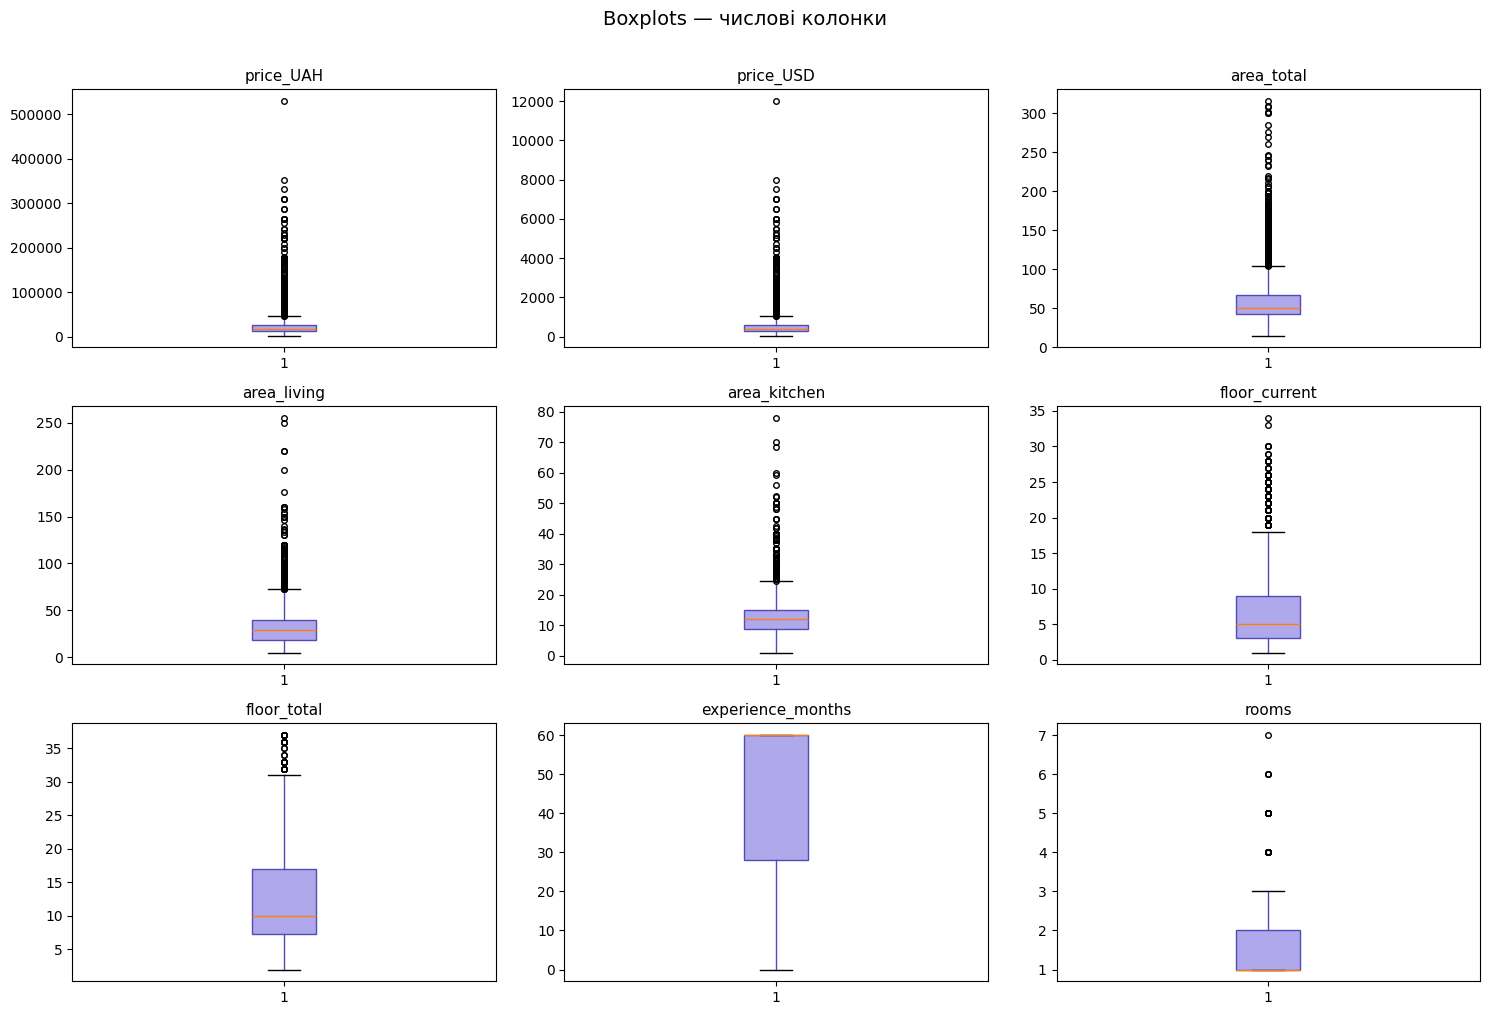

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(cl_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AFA9EC', color='#534AB7'),
                    whiskerprops=dict(color='#534AB7'),
                    flierprops=dict(marker='o', color='#D85A30', markersize=4))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — числові колонки', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

В результаті маємо готові дані для аналізу і побудови гіпотез, в залежності від напрямку аналізу будемо розділяти дані квартир на 2 датасети (звичайні vs преміум).

#### Перевірка бінарних (лише коректність)

Для впевненості у бінарних колонках перевіримо значення цих колонок.

In [52]:
print("=== Перевірка бінарних колонок (допустимі значення: 0 або 1) ===")
for col in binary_cols:
    unique_vals = cl_df[col].unique()
    bad = [v for v in unique_vals if v not in [0, 1]]
    if bad:
        print(f"  ⚠️  {col}: знайдено дивні значення → {bad}")
    else:
        print(f"  ✅ {col}: OK ({cl_df[col].value_counts().to_dict()})")

=== Перевірка бінарних колонок (допустимі значення: 0 або 1) ===
  ✅ kitchen_studio: OK ({0: 4085, 1: 1561})
  ✅ penthouse: OK ({0: 5615, 1: 31})
  ✅ multilevel: OK ({0: 5572, 1: 74})
  ✅ has_shelter: OK ({0: 4167, 1: 1479})
  ✅ no_light_internet: OK ({0: 3664, 1: 1982})
  ✅ no_light_mobile_connection: OK ({0: 3399, 1: 2247})
  ✅ no_light_water: OK ({0: 2890, 1: 2756})
  ✅ no_light_heating: OK ({0: 3532, 1: 2114})
  ✅ no_light_gas: OK ({0: 4038, 1: 1608})
  ✅ no_light_elevator: OK ({0: 4441, 1: 1205})
  ✅ has_metro: OK ({0: 4026, 1: 1620})


#### Перевірка категоріальних

In [53]:
print("=== Рідкісні категорії (< 1% = підозрілі) ===")
for col in categorical_cols:
    counts = cl_df[col].value_counts(normalize=True) * 100
    rare = counts[counts < 1.0]
    print(f"\n{col}:")
    print(counts.round(2).to_string())
    if not rare.empty:
        print(f"  ⚠️  Рідкісні значення: {rare.index.tolist()}")

=== Рідкісні категорії (< 1% = підозрілі) ===

seller_level:
seller_level
Експерт        52.36
Досвідчений    19.16
Новачок        14.59
Професіонал    13.89

pets:
pets
Не вказано           52.07
Без тварин           29.61
Можна з тваринами    18.31

city_name:
city_name
Київ                          35.72
Вінниця                       10.82
Одеса                         10.57
Дніпро                         9.14
Львів                          5.60
Хмельницький                   4.78
Тернопіль                      4.20
Рівне                          3.37
Івано-Франківськ               2.39
Харків                         1.68
Миколаїв                       1.19
Ірпінь                         1.12
Софіївська Борщагівка          1.04
Луцьк                          0.81
Чернівці                       0.74
Біла Церква                    0.62
Полтава                        0.55
Ужгород                        0.46
Лиманка                        0.44
Кривий Ріг                     0.37
Житомир

В категоріальних даних нічого не видаляємо, просто ознайомилися з існуючими категоріями.

In [54]:
cl_df.info()

<class 'pandas.DataFrame'>
Index: 5646 entries, 222 to 6208
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          5646 non-null   str           
 1   rooms                       5646 non-null   Int64         
 2   price_UAH                   5646 non-null   Int64         
 3   price_USD                   5646 non-null   Int64         
 4   date                        5646 non-null   datetime64[us]
 5   city_name                   5646 non-null   str           
 6   district                    5646 non-null   str           
 7   metro                       5646 non-null   str           
 8   address                     5646 non-null   str           
 9   seller                      5646 non-null   str           
 10  experience_months           5646 non-null   int64         
 11  seller_level                5646 non-null   str           
 12  area_t

Також не було проаналізованого стовпчики `id`, `date`, `address`, `url`, `seller`, `metro` так як вони використовуються для позначення унікальності оголошення або інших не аналізуючих в цьому випадку особливостей.

### 3. Аналіз

C:\Users\Acer\AppData\Local\Temp\ipykernel_28372\1319112852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


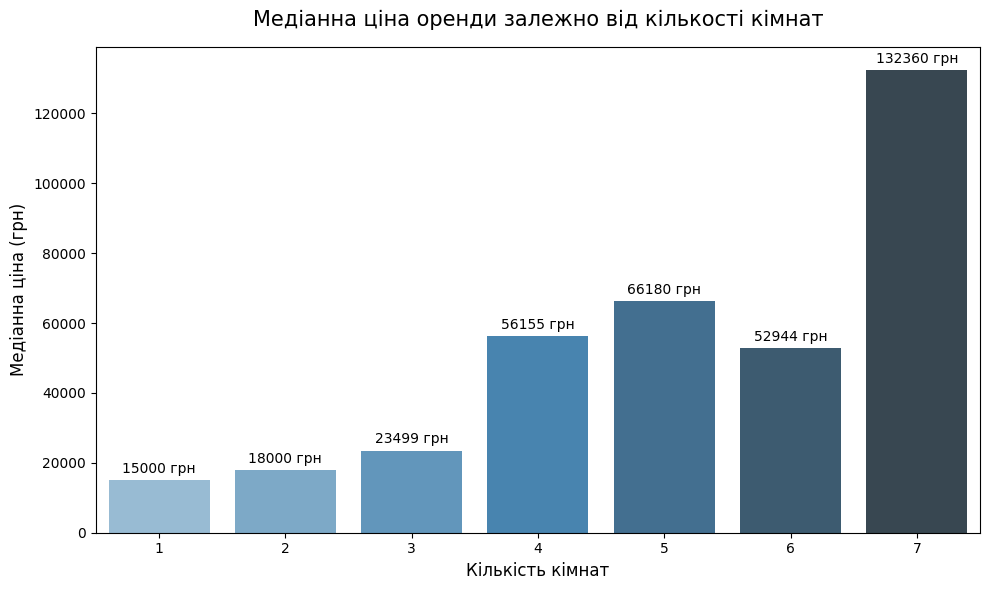

C:\Users\Acer\AppData\Local\Temp\ipykernel_28372\1319112852.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


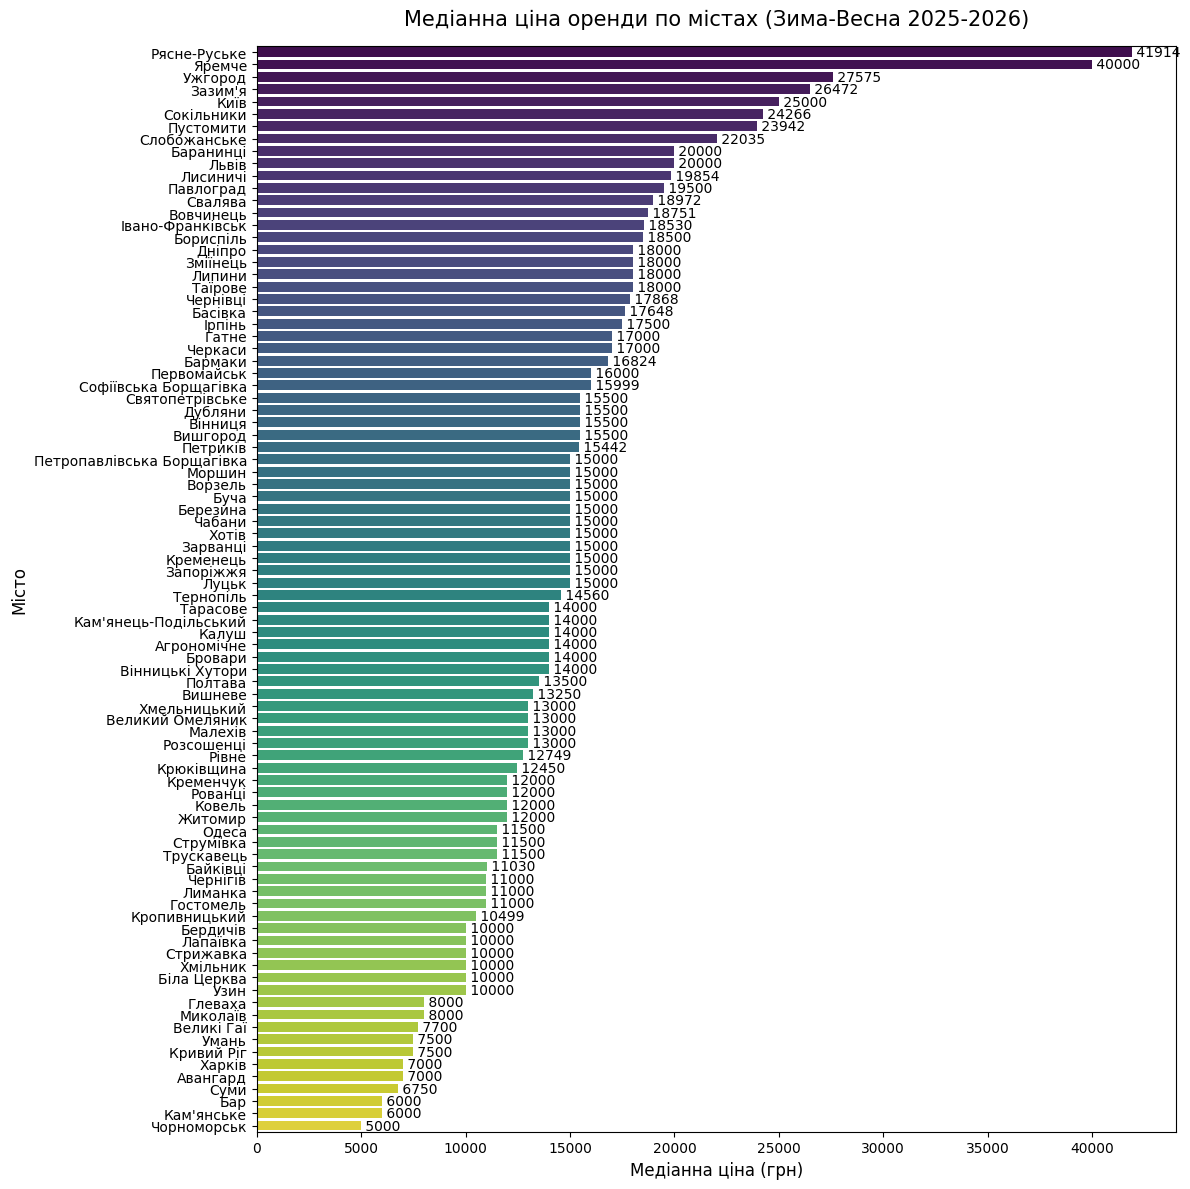

In [61]:
# ==========================================
# ГРАФІК 1: Ціна відносно кількості кімнат
# ==========================================
plt.figure(figsize=(10, 6))

# Будуємо вертикальний графік
ax1 = sns.barplot(
    data=cl_df, 
    x='rooms', 
    y='price_UAH', 
    estimator=np.median, # Рахуємо медіану
    errorbar=None,       # Прибираємо "вусики"
    palette='Blues_d'    # Градієнт синього
)

plt.title('Медіанна ціна оренди залежно від кількості кімнат', fontsize=15, pad=15)
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Додаємо точні цифри над кожним стовпчиком
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d грн', padding=3)

plt.tight_layout()
plt.show()


# ==========================================
# ГРАФІК 2: Ціна по містах України
# ==========================================
# Робимо графік високим (12 дюймів), бо міст багато і їм треба місце
plt.figure(figsize=(12, 12)) 

# Сортуємо міста за медіанною ціною (від найдорожчого до найдешевшого)
city_order = cl_df.groupby('city_name')['price_UAH'].median().sort_values(ascending=False).index

# Будуємо горизонтальний графік
ax2 = sns.barplot(
    data=cl_df, 
    y='city_name', 
    x='price_UAH', 
    estimator=np.median,
    errorbar=None,
    order=city_order,
    palette='viridis' # Яскрава палітра від жовтого до фіолетового
)

plt.title('Медіанна ціна оренди по містах (Зима-Весна 2025-2026)', fontsize=15, pad=15)
plt.xlabel('Медіанна ціна (грн)', fontsize=12)
plt.ylabel('Місто', fontsize=12)

# Додаємо точні цифри поруч із кожним стовпчиком
for p in ax2.patches:
    # Оскільки графік горизонтальний, ми беремо width (ширину), а не height (висоту)
    ax2.annotate(f" {int(p.get_width())}", 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [63]:
cl_df.head(3)

,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,year_month,price_per_sqm
222,33956641,1,15000,340,2026-03-27,Київ,Харківський Масив,Вирлиця,вул. Кам’янська 6,Олена Гранд,18,Досвідчений,30.0,18.0,6.0,25,25,0,0,0,1,Не вказано,0,0,1,0,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kiev-harkovskiy-massiv-kamenskaya-ulitsa-33956641.html,1,2026-03,500.0
212,33463352,1,9000,204,2026-03-27,Хмельницький,Ракове,Немає метро,"вул. Чорновола В’ячеслава 176/1, кв. 143",Юрій Анатолійович Яремчук,60,Експерт,55.7,17.4,11.3,1,4,0,0,0,0,Без тварин,0,0,0,0,0,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-hmelnitskiy-rakovo-chernovola-vyacheslava-ulitsa-33463352.html,0,2026-03,161.579892
214,33671390,1,30884,700,2026-03-27,Одеса,Аркадія,Немає метро,пров. Курортний 2,Олександр,28,Досвідчений,45.0,18.0,11.9,18,25,1,0,0,1,Без тварин,0,0,1,1,0,1,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-arkadiya-kurortnyy-pereulok-33671390.html,0,2026-03,686.311111


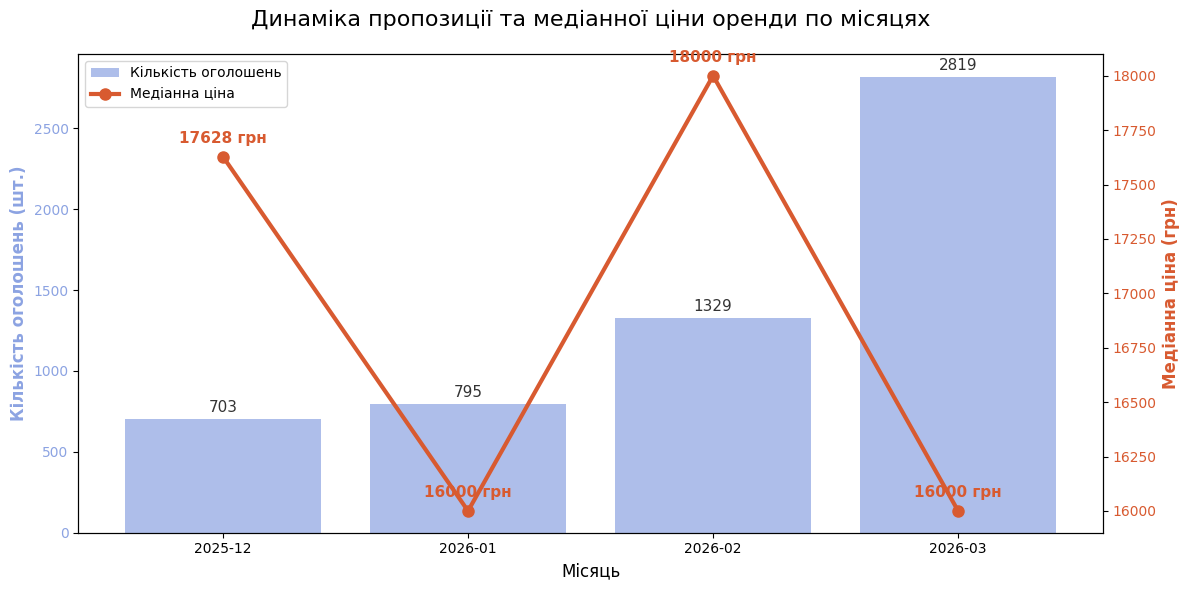


Детальна статистика по місяцях:
 Місяць  К-сть квартир  Медіанна ціна (грн)
2025-12            703              17628.0
2026-01            795              16000.0
2026-02           1329              18000.0
2026-03           2819              16000.0


In [64]:

# 1. Підготовка даних
# Групуємо дані по місяцях і рахуємо одночасно два показники: 'count' (кількість) і 'median' (медіана)
monthly_stats = cl_df.groupby('year_month')['price_UAH'].agg(['count', 'median']).reset_index()

# Перетворюємо місяці у звичайний текст (бо matplotlib іноді свариться на спеціальний формат period[M])
monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)

# 2. Будуємо графік
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- ПЕРША ВІСЬ (Стовпчики: Кількість оголошень) ---
color_count = '#8CA3E2' # М'який синій колір
ax1.bar(monthly_stats['year_month'], monthly_stats['count'], color=color_count, alpha=0.7, label='Кількість оголошень')

ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('Кількість оголошень (шт.)', color=color_count, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_count)

# Додаємо цифри кількості прямо на стовпчики (використовуємо наш новий улюблений метод)
ax1.bar_label(ax1.containers[0], padding=3, color='#333333', fontsize=11)


# --- ДРУГА ВІСЬ (Лінія: Медіанна ціна) ---
# МАГІЯ ТУТ: ax1.twinx() створює другу вісь Y, яка ділить ту саму вісь X (місяці)
ax2 = ax1.twinx() 
color_price = '#D85A30' # Контрастний помаранчевий/червоний колір

# Малюємо лінію цін поверх стовпчиків
ax2.plot(monthly_stats['year_month'], monthly_stats['median'], color=color_price, 
         marker='o', linewidth=3, markersize=8, label='Медіанна ціна')

ax2.set_ylabel('Медіанна ціна (грн)', color=color_price, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_price)

# Додаємо точні цифри цін над точками лінії
for i, price in enumerate(monthly_stats['median']):
    ax2.annotate(f"{int(price)} грн", 
                 (i, price), 
                 textcoords="offset points", 
                 xytext=(0, 10), # Трохи піднімаємо текст над точкою
                 ha='center', fontsize=11, color=color_price, fontweight='bold')


# --- КОСМЕТИКА ---
plt.title('Динаміка пропозиції та медіанної ціни оренди по місяцях', fontsize=16, pad=20)

# Збираємо легенду з обох осей до купи, щоб було красиво
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Вимикаємо сітку на другій осі, щоб лінії не перетиналися і не робили "кашу"
ax2.grid(False)

plt.tight_layout()
plt.show()

# Виводимо табличку для підтвердження
print("\nДетальна статистика по місяцях:")
print(monthly_stats.rename(columns={'year_month': 'Місяць', 'count': 'К-сть квартир', 'median': 'Медіанна ціна (грн)'}).to_string(index=False))

C:\Users\Acer\AppData\Local\Temp\ipykernel_28372\2003703107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\Acer\AppData\Local\Temp\ipykernel_28372\2003703107.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Ні', 'Так', 'Не вказано'])


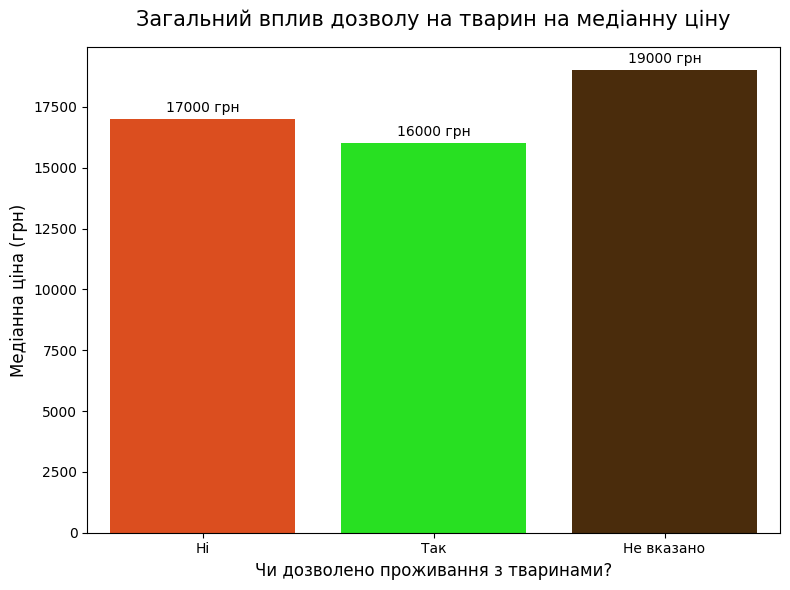

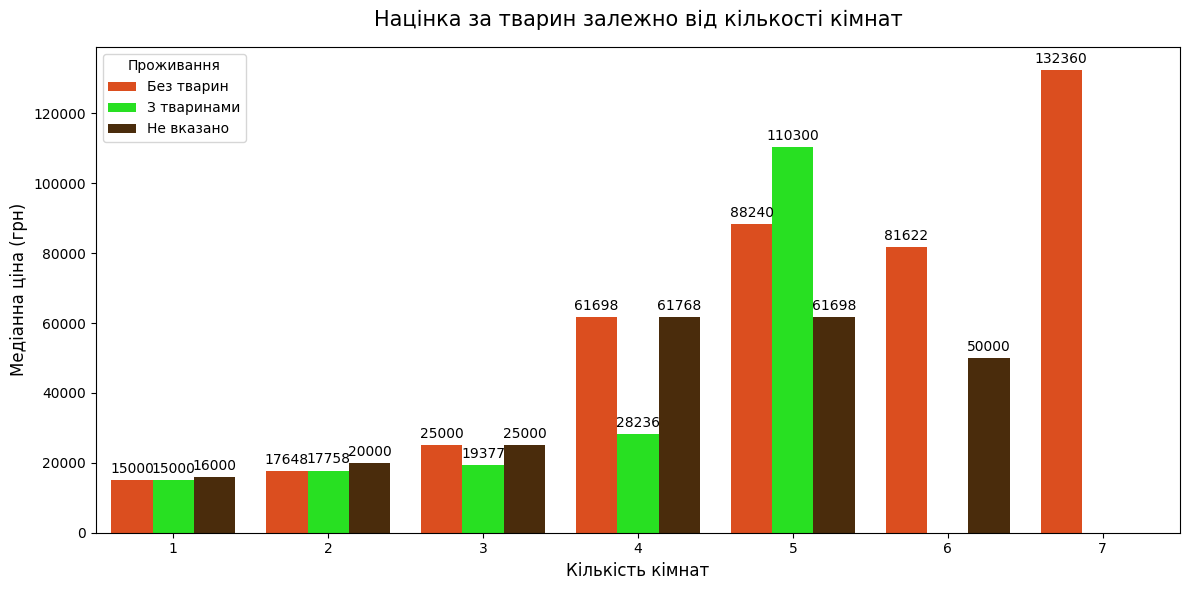


Точні цифри медіанної ціни (грн) по кімнатах та тваринах:
pets   Без тварин  Можна з тваринами  Не вказано
rooms                                           
1         15000.0            16000.0     15000.0
2         17758.0            20000.0     17648.0
3         19377.0            25000.0     25000.0
4         28236.0            61768.0     61698.0
5        110300.0            61698.0     88240.0
6            <NA>            50000.0     81622.0
7            <NA>               <NA>    132360.0


In [70]:
# Заміни 'pets_allowed' на точну назву твоєї колонки з тваринами!
pet_col = 'pets' 

# ==========================================
# ГРАФІК 1: Загальний вплив тварин на ціну
# ==========================================
plt.figure(figsize=(8, 6))
ax1 = sns.barplot(
    data=cl_df, 
    x=pet_col, 
    y='price_UAH', 
    estimator=np.median, 
    errorbar=None,
    palette=["#FA3E00", "#0BFF03", "#552C01A9"] # Червоний (Ні) і Синій (Так)
)

plt.title('Загальний вплив дозволу на тварин на медіанну ціну', fontsize=15, pad=15)
plt.xlabel('Чи дозволено проживання з тваринами?', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Якщо в тебе значення 0 і 1, підпишемо їх по-людськи:
ax1.set_xticklabels(['Ні', 'Так', 'Не вказано'])

# Автоматично підписуємо стовпчики
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d грн', padding=3)

# ax1.bar_label(ax1.containers[0], fmt='%d грн', padding=3, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# ==========================================
# ГРАФІК 2: Націнка за тварин по кімнатах
# ==========================================
plt.figure(figsize=(12, 6))

ax2 = sns.barplot(
    data=cl_df, 
    x='rooms', 
    y='price_UAH', 
    hue=pet_col,          # Розбиваємо кожен стовпчик кімнат на два (з тваринами і без)
    estimator=np.median, 
    errorbar=None,
    palette=["#FA3E00", "#0BFF03", "#552C01A9"]
)

plt.title('Націнка за тварин залежно від кількості кімнат', fontsize=15, pad=15)
plt.xlabel('Кількість кімнат', fontsize=12)
plt.ylabel('Медіанна ціна (грн)', fontsize=12)

# Налаштовуємо легенду
handles, labels = ax2.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Без тварин', 'З тваринами', 'Не вказано'], title='Проживання', loc='upper left')

# Оскільки в нас є hue (дві групи стовпчиків), використовуємо цикл по контейнерах, 
# про який ми говорили раніше, щоб підписати їх усі!
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# Текстова статистика для підтвердження
print("\nТочні цифри медіанної ціни (грн) по кімнатах та тваринах:")
print(cl_df.pivot_table(values='price_UAH', index='rooms', columns=pet_col, aggfunc='median').round(0))